In [1]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 38
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

2

[('38a1', [(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)]), ('38b1', [(1, 1), (2, 1), (3, -1), (4, 1), (5, -4)])]

('38a1', [(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)])

[(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)]


In [32]:
nth_prime(400)

2741

In [1]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 38
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list=[pair for pair in expansion if is_prime(pair[0]-1)]
coeffs_list=[pair[1] for pair in prime_list]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run13april26no1.txt', 'wb') as wfile:
    pickle.dump(prime_list, wfile) 
    
with open('/Users/barrybrent/data2/run13april26no2.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 38a1
(1, 1)
(2, 1)
(3, -5)
(4, 1)
(5, 11)
(6, -11)
(7, 8)
(8, 17)
(9, -32)
(10, 11)
(11, 34)
(12, -95)
(13, 53)
(14, 8)
(15, -130)
(16, 209)
(17, 1)
(18, -326)
(19, 723)
(20, -209)
(21, -1090)
(22, 2036)
(23, -896)
(24, -3031)
(25, 5861)
(26, -2807)
(27, -7619)
(28, 15772)
(29, -7133)
(30, -19366)
(31, 41076)
(32, -20463)
(33, -46832)
(34, 103259)
(35, -59902)
(36, -107258)
(37, 261110)
(38, -177421)
(39, -229156)
(40, 657847)
(41, -521765)
(42, -469144)
(43, 1667068)
(44, -1541000)
(45, -895522)
(46, 4225630)
(47, -4467913)
(48, -1532359)
(49, 10721551)
(50, -12682689)
(51, -2016851)
(52, 27062309)
(53, -35296515)
(54, -442235)
(55, 67713624)
(56, -96706852)
(57, 10928244)
(58, 167349953)
(59, -261325100)
(60, 59394310)
(61, 407895960)
(62, -698448940)
(63, 234902006)
(64, 978740753)
(65, -1850586597)
(66, 819118520)
(67, 2308231942)
(68, -4868633637)
(69, 2665302532)
(70, 5337686358)
(71, -12725618401)
(72, 8287406750)
(73, 12058972931)
(74, -33051560280)
(75, 24933653345)
(76

1 0.00016111532847086588
2 0.001140900452931722
3 0.0015397032101949057
4 0.001625518004099528
5 0.0016825000445048015
6 0.0017347375551859537
7 0.001763916015625
8 0.0018040696779886881
9 0.001901217301686605
10 0.0019595861434936524
11 0.0020503997802734375
12 0.002116700013478597
13 0.002219549814860026
14 0.002311968803405762
15 0.002412001291910807
16 0.0025256832440694174
17 0.002676999568939209
18 0.0028765519460042317
19 0.003119087219238281
20 0.0033188343048095705
21 0.0035382866859436034
22 0.0037682175636291502
23 0.0041361649831136065
24 0.004421385129292806
25 0.004771184921264648
26 0.005230414867401123
27 0.005626734097798665
28 0.006144801775614421
29 0.006621138254801432
30 0.00714720090230306
31 0.007665185133616129
32 0.008194168408711752
33 0.008747231960296632
34 0.009350351492563884
35 0.00998843510945638
36 0.010697571436564128
37 0.011601285139719645
38 0.012428430716196696
39 0.013376303513844808
40 0.014355599880218506
41 0.015350886185963948
42 0.01644013722

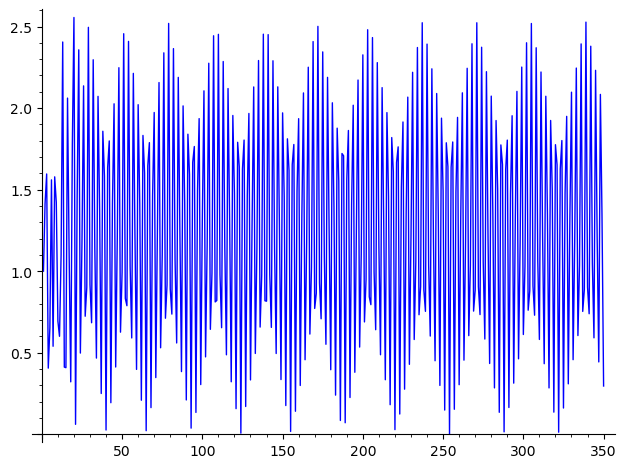

In [2]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()

with open('/Users/barrybrent/data2/run13april26no2.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    now=time.time()
    print(n, (now-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run13april26no3.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run13april26no4.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run13april26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
